In [1]:
from google.colab import files

uploaded = files.upload()

Saving logistics_cleaned.csv to logistics_cleaned.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("logistics_cleaned.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Dataset Shape:", df.shape)

Dataset Shape: (32065, 26)


Define the prediction target

In [3]:
target = "delivery_time_deviation"

In [4]:
target = "delivery_time_deviation"

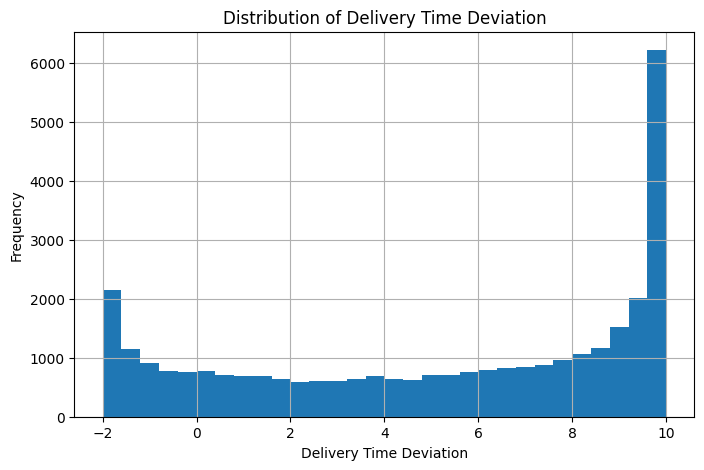

In [5]:
df["delivery_time_deviation"].hist(bins=30, figsize=(8,5))

plt.title("Distribution of Delivery Time Deviation")
plt.xlabel("Delivery Time Deviation")
plt.ylabel("Frequency")

plt.show()

Select features

In [6]:
features = [
    "vehicle_gps_latitude",
    "vehicle_gps_longitude",
    "fuel_consumption_rate",
    "eta_variation_hours",
    "traffic_congestion_level",
    "warehouse_inventory_level",
    "loading_unloading_time",
    "handling_equipment_availability",
    "order_fulfillment_status",
    "weather_condition_severity",
    "port_congestion_level",
    "shipping_costs",
    "supplier_reliability_score",
    "lead_time_days",
    "historical_demand",
    "iot_temperature",
    "cargo_condition_status",
    "route_risk_level",
    "customs_clearance_time",
    "driver_behavior_score",
    "fatigue_monitoring_score",
    "disruption_likelihood_score",
    "delay_probability"
]

X = df[features]
y = df[target]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (32065, 23)
Target: (32065,)


Train-test split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (25652, 23)
Testing data: (6413, 23)


Model 1: Linear Regression

In [8]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression
MAE: 3.7049295355049585
RMSE: 4.153719344125966
R² Score: -0.0005233124591315086


Model 2: Decision Tree

In [10]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

In [11]:
tree_mae = mean_absolute_error(y_test, tree_predictions)

tree_rmse = np.sqrt(
    mean_squared_error(y_test, tree_predictions)
)

tree_r2 = r2_score(y_test, tree_predictions)

print("Decision Tree")
print("MAE:", tree_mae)
print("RMSE:", tree_rmse)
print("R² Score:", tree_r2)

Decision Tree
MAE: 3.775913078617148
RMSE: 4.3016989605800005
R² Score: -0.0730820819981759


Random Forest

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [13]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest
MAE: 3.7073858669554975
RMSE: 4.158943477191619
R² Score: -0.0030416115552844847


Compare all models

In [14]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        tree_r2,
        rf_r2
    ]
})

model_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.704930,4.153719,-0.000523
1,Decision Tree,3.775913,4.301699,-0.073082
2,Random Forest,3.707386,4.158943,-0.003042


Cross-validation

In [15]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross-validation R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

Cross-validation R² scores: [-0.00455532 -0.00898938 -0.00518785 -0.00606862 -0.00761609]
Mean CV R²: -0.006483450019151338


Feature Importance

In [16]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,loading_unloading_time,0.047544
20,fatigue_monitoring_score,0.046493
18,customs_clearance_time,0.046211
9,weather_condition_severity,0.045498
3,eta_variation_hours,0.044720
5,warehouse_inventory_level,0.044693
7,handling_equipment_availability,0.043943
2,fuel_consumption_rate,0.043811
12,supplier_reliability_score,0.043674
10,port_congestion_level,0.043249


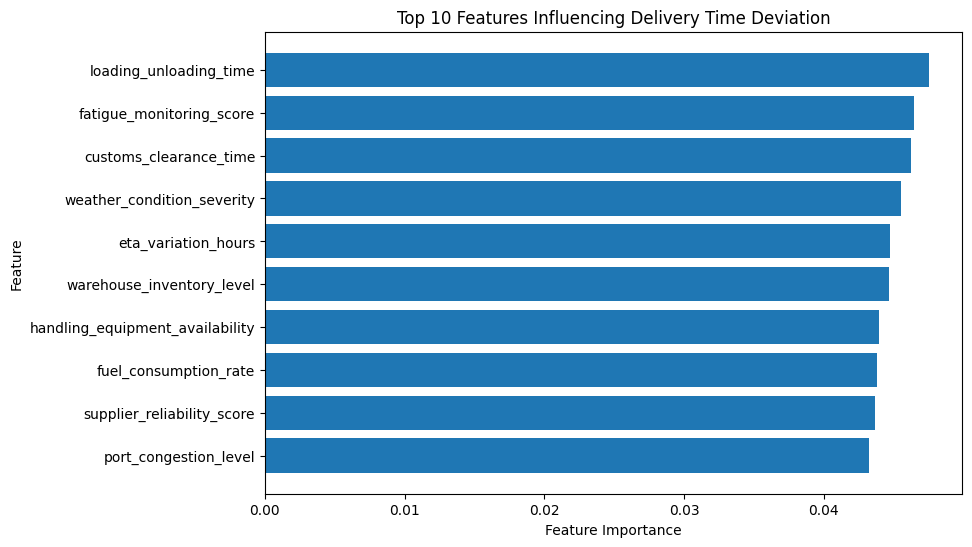

In [17]:
plt.figure(figsize=(9,6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Features Influencing Delivery Time Deviation")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

Actual vs Predicted Values

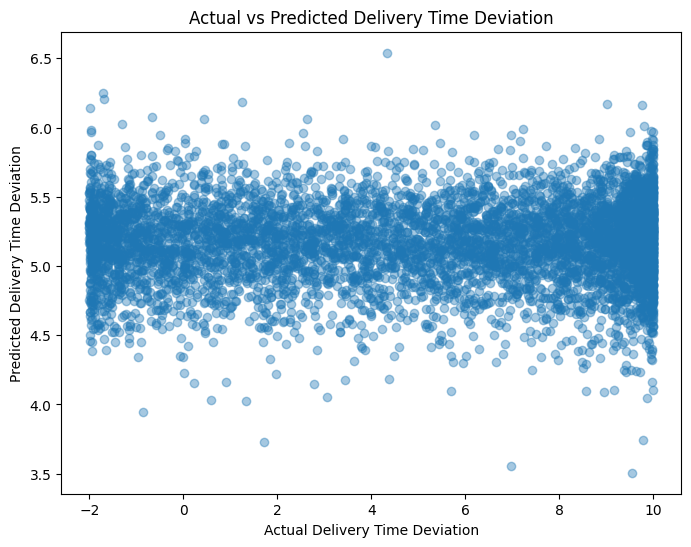

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.4
)

plt.xlabel("Actual Delivery Time Deviation")
plt.ylabel("Predicted Delivery Time Deviation")

plt.title("Actual vs Predicted Delivery Time Deviation")

plt.show()

In [19]:
model_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.704930,4.153719,-0.000523
1,Decision Tree,3.775913,4.301699,-0.073082
2,Random Forest,3.707386,4.158943,-0.003042


In [20]:
feature_importance.head(10)

,Feature,Importance
6,loading_unloading_time,0.047544
20,fatigue_monitoring_score,0.046493
18,customs_clearance_time,0.046211
9,weather_condition_severity,0.045498
3,eta_variation_hours,0.044720
5,warehouse_inventory_level,0.044693
7,handling_equipment_availability,0.043943
2,fuel_consumption_rate,0.043811
12,supplier_reliability_score,0.043674
10,port_congestion_level,0.043249


In [21]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross-validation R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

Cross-validation R² scores: [-0.00455532 -0.00898938 -0.00518785 -0.00606862 -0.00761609]
Mean CV R²: -0.006483450019151382


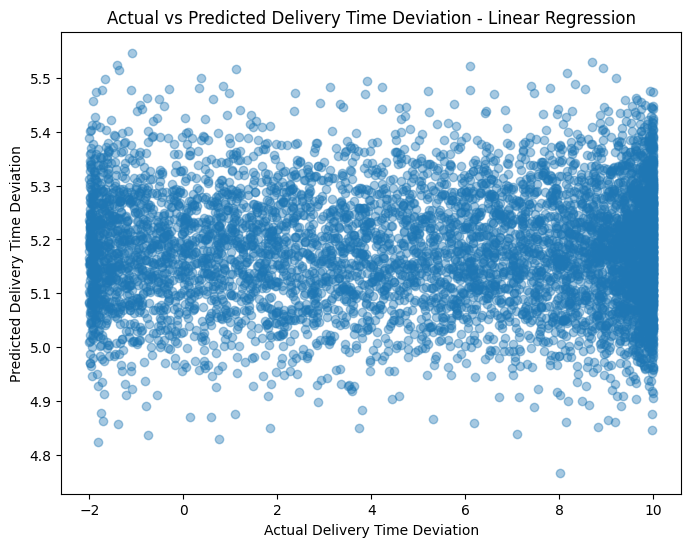

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.4
)

plt.xlabel("Actual Delivery Time Deviation")
plt.ylabel("Predicted Delivery Time Deviation")
plt.title("Actual vs Predicted Delivery Time Deviation - Linear Regression")

plt.show()